# Red Neuronal Recurrentepara Prediccion de Series de Tiempo

Dataset: Airline Passengers (Box & Jenkins) — pasajeros mensuales 1949-1960
Modelos: RNN simple, LSTM, GRU — comparacion de las tres arquitecturas
Framework: TensorFlow / Keras

**Flujo del notebook:**
1. Explicacion conceptual de RNN/LSTM/GRU
2. Carga y exploracion del dataset
3. Preprocesamiento y ventanas temporales
4. Implementacion y entrenamiento de los modelos
5. Evaluacion con metricas
6. Visualizacion de predicciones
7. Analisis de comportamiento y sobreajuste
8. Conclusiones

---

## 1. Redes Neuronales Recurrentes para Series de Tiempo


Las redes densas convencionales tratan cada muestra de forma independiente.
Las redes recurrentes (RNN) mantienen un estado oculto que se actualiza
en cada paso temporal, permitiendo capturar dependencias entre valores pasados
y el valor actual.


### Arquitecturas comparadas

| Modelo | Mecanismo | Ventaja |
|--------|-----------|----------|
| **RNN Simple** | Estado oculto basico | Rapida, pero sufre vanishing gradient |
| **LSTM** | Celda con gates (input, forget, output) | Captura dependencias largas |
| **GRU** | Gates simplificados (reset, update) | Balance entre LSTM y RNN simple |

### Estrategia de ventanas temporales

El dataset se organiza en ventanas de `window_size` pasos como entrada
y el siguiente valor como objetivo.

## 2. Importaciones y configuracion

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print("TensorFlow:", tf.__version__)
print("Configuracion lista.")

TensorFlow: 2.20.0
Configuracion lista.


## 3. Dataset Airline Passengers

Airline Passengers es un dataset clasico de series de tiempo:
- Numero mensual de pasajeros aereos internacionales (miles)
- Periodo: enero 1949 — diciembre 1960 (144 meses)
- Caracteristicas: tendencia creciente + estacionalidad anual

Es un benchmark ampliamente usado para evaluar modelos de prediccion temporal
por su estructura clara de tendencia y estacionalidad.

Registros  : 144
Periodo    : Jan 1949 — Dec 1960
Min/Max    : 104 / 622 miles de pasajeros

            Pasajeros
Mes                  
1949-01-01        112
1949-02-01        118
1949-03-01        132
1949-04-01        129
1949-05-01        121
1949-06-01        135
1949-07-01        148
1949-08-01        148
1949-09-01        136
1949-10-01        119
1949-11-01        104
1949-12-01        118


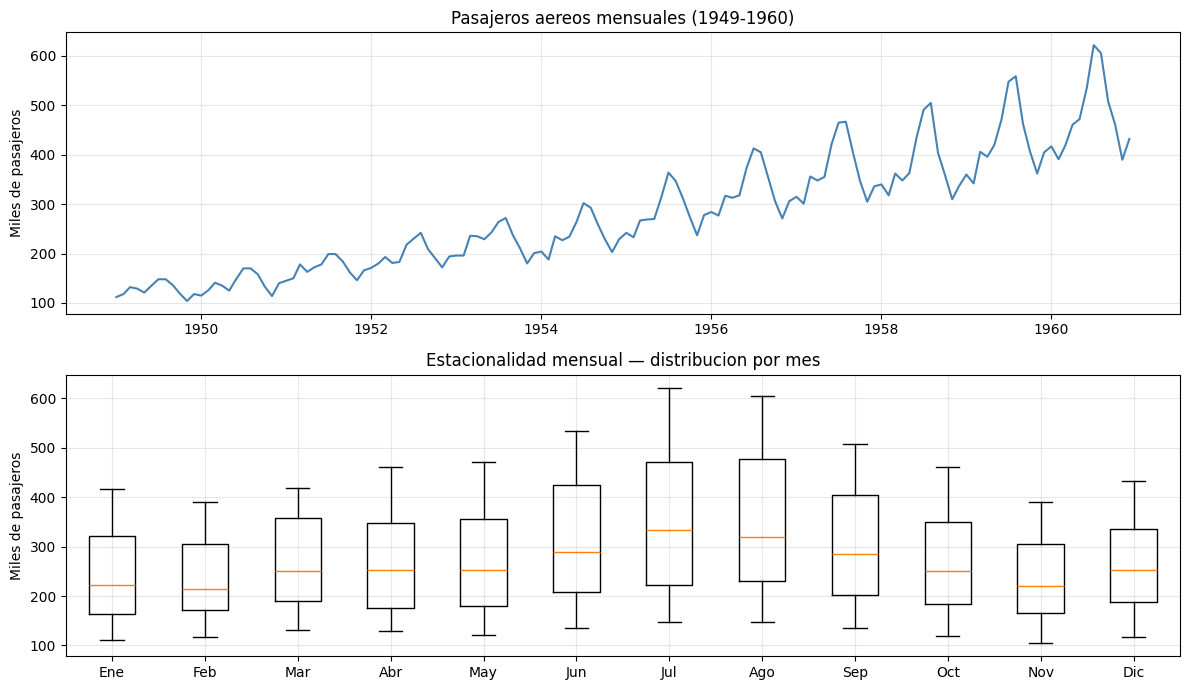

In [2]:
# Cargar dataset Airline Passengers directamente desde URL publica
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, header=0, names=["Mes", "Pasajeros"])
df["Mes"] = pd.to_datetime(df["Mes"])
df.set_index("Mes", inplace=True)

print(f"Registros  : {len(df)}")
print(f"Periodo    : {df.index.min().strftime("%b %Y")} — {df.index.max().strftime("%b %Y")}")
print(f"Min/Max    : {df.Pasajeros.min()} / {df.Pasajeros.max()} miles de pasajeros")
print()
print(df.head(12))

# Visualizar la serie de tiempo completa
fig, axes = plt.subplots(2, 1, figsize=(12, 7))

# Serie original
axes[0].plot(df.index, df.Pasajeros, color="steelblue", linewidth=1.5)
axes[0].set_title("Pasajeros aereos mensuales (1949-1960)", fontsize=12)
axes[0].set_ylabel("Miles de pasajeros")
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[0].grid(alpha=0.3)

# Boxplot por mes para ver estacionalidad
df["Mes_num"] = df.index.month
meses = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]
datos_mensuales = [df[df.Mes_num == m].Pasajeros.values for m in range(1, 13)]
axes[1].boxplot(datos_mensuales, labels=meses)
axes[1].set_title("Estacionalidad mensual — distribucion por mes", fontsize=12)
axes[1].set_ylabel("Miles de pasajeros")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Preprocesamiento Normalizacion y Ventanas Temporales

**Normalizacion:** escalar los valores a [0, 1] con MinMaxScaler.
Las RNN son sensibles a la escala de los datos, valores grandes pueden causar
explosiones de gradiente.

**Division train/test:**
- Entrenamiento: primeros 80% de la serie (sin shuffle — el orden temporal es critico)
- Test: ultimo 20%

**Ventanas temporales:** cada muestra de entrenamiento es una secuencia de
`WINDOW_SIZE` pasos consecutivos, y el objetivo es el siguiente valor.
Se usa `WINDOW_SIZE = 12` (un ano) para capturar la estacionalidad anual.

In [3]:
WINDOW_SIZE = 12   # ventana de 12 meses para capturar estacionalidad anual

# Extraer valores como array y normalizar a [0, 1]
valores = df.Pasajeros.values.reshape(-1, 1).astype("float32")
scaler  = MinMaxScaler(feature_range=(0, 1))
valores_norm = scaler.fit_transform(valores)

# Division temporal: 80% train, 20% test (sin shuffle)
n_total = len(valores_norm)
n_train = int(n_total * 0.80)
train_data = valores_norm[:n_train]
test_data  = valores_norm[n_train:]

print(f"Total muestras : {n_total}")
print(f"Train          : {n_train} muestras ({n_train/n_total:.0%})")
print(f"Test           : {n_total - n_train} muestras ({(n_total-n_train)/n_total:.0%})")
print(f"Window size    : {WINDOW_SIZE} pasos")


def crear_ventanas(serie, window_size):
    """
    Convierte una serie de tiempo en pares (X, y) de ventanas temporales.

    Para cada posicion t:
        X[t] = [serie[t], serie[t+1], ..., serie[t+window_size-1]]
        y[t] = serie[t+window_size]

    Parametros:
        serie       : array 1D de valores normalizados
        window_size : numero de pasos de entrada
    Retorna:
        X : (n_muestras, window_size, 1)
        y : (n_muestras,)
    """
    X, y = [], []
    for i in range(len(serie) - window_size):
        X.append(serie[i : i + window_size])       # ventana de entrada
        y.append(serie[i + window_size])           # siguiente valor
    return np.array(X, dtype="float32"), np.array(y, dtype="float32")


# Crear ventanas para train y test
X_train, y_train = crear_ventanas(train_data, WINDOW_SIZE)

# Para test: incluir los ultimos WINDOW_SIZE puntos de train como contexto inicial
test_data_ctx = np.concatenate([train_data[-WINDOW_SIZE:], test_data])
X_test, y_test = crear_ventanas(test_data_ctx, WINDOW_SIZE)

print(f"\nX_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_test : {X_test.shape}   y_test : {y_test.shape}")

Total muestras : 144
Train          : 115 muestras (80%)
Test           : 29 muestras (20%)
Window size    : 12 pasos

X_train: (103, 12, 1)  y_train: (103, 1)
X_test : (29, 12, 1)   y_test : (29, 1)


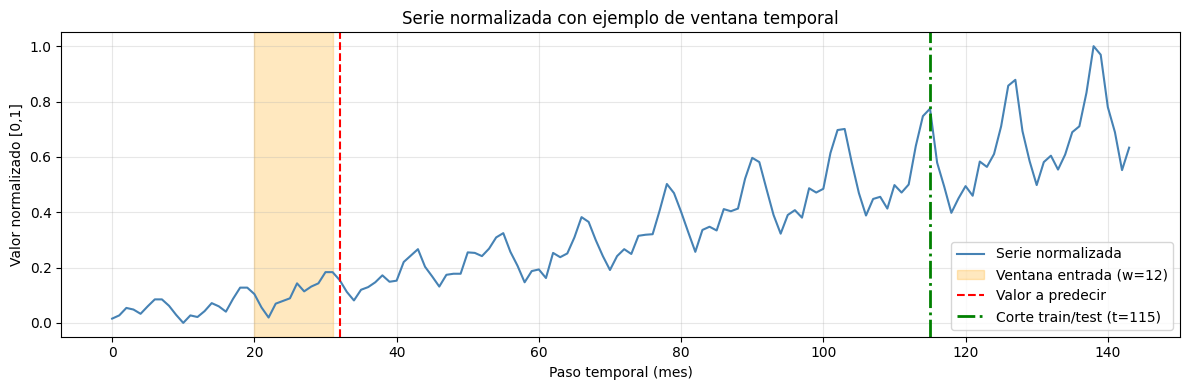

In [4]:
# Visualizar como se construye una ventana temporal
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(range(n_total), valores_norm.flatten(),
        color="steelblue", linewidth=1.5, label="Serie normalizada")

# Marcar un ejemplo de ventana
ejemplo_inicio = 20
ax.axvspan(ejemplo_inicio, ejemplo_inicio + WINDOW_SIZE - 1,
           alpha=0.25, color="orange", label=f"Ventana entrada (w={WINDOW_SIZE})")
ax.axvline(ejemplo_inicio + WINDOW_SIZE, color="red", linestyle="--",
           label="Valor a predecir")
ax.axvline(n_train, color="green", linestyle="-.", linewidth=2,
           label=f"Corte train/test (t={n_train})")

ax.set_title("Serie normalizada con ejemplo de ventana temporal")
ax.set_xlabel("Paso temporal (mes)")
ax.set_ylabel("Valor normalizado [0,1]")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Implementacion de los modelos recurrentes

Se implementan y comparan tres arquitecturas:
- **RNN Simple:** capa `SimpleRNN` — baseline recurrente
- **LSTM:** Long Short-Term Memory — captura dependencias largas con gates
- **GRU:** Gated Recurrent Unit — version simplificada del LSTM

La cabeza de regresion es identica en los tres: `Dense(1)` sin activacion
(prediccion de valor continuo).

In [5]:
def construir_modelo(tipo="LSTM", window_size=12, unidades=64):
    """
    Construye un modelo recurrente para prediccion de series de tiempo.

    Parametros:
        tipo        : "RNN", "LSTM" o "GRU"
        window_size : longitud de la ventana de entrada
        unidades    : numero de unidades en la capa recurrente

    Retorna:
        modelo compilado
    """
    # Seleccionar la capa recurrente segun el tipo
    capas_recurrentes = {
        "RNN":  layers.SimpleRNN(unidades, return_sequences=False),
        "LSTM": layers.LSTM(unidades, return_sequences=False),
        "GRU":  layers.GRU(unidades, return_sequences=False),
    }
    assert tipo in capas_recurrentes, f"tipo debe ser uno de {list(capas_recurrentes.keys())}"

    modelo = keras.Sequential([
        layers.Input(shape=(window_size, 1)),   # (pasos_temporales, features)

        # Capa recurrente: procesa la secuencia y retorna el estado final
        capas_recurrentes[tipo],

        # Regularizacion para reducir sobreajuste
        layers.Dropout(0.2),

        # Cabeza de regresion: predice un unico valor continuo
        layers.Dense(32, activation="relu"),
        layers.Dense(1),    # sin activacion — prediccion de valor real
    ], name=f"Modelo_{tipo}")

    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",           # MSE es la metrica estandar para regresion
        metrics=["mae"]       # MAE complementa al MSE (menos sensible a outliers)
    )
    return modelo


# Construir los tres modelos
modelo_rnn  = construir_modelo("RNN")
modelo_lstm = construir_modelo("LSTM")
modelo_gru  = construir_modelo("GRU")

# Mostrar arquitectura del LSTM como representativa
modelo_lstm.summary()

Model: "Modelo_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Entrenamiento de los modelos

**Hiperparametros:**
- Optimizador: Adam con LR=1e-3
- Loss: MSE (Mean Squared Error) — estandar para regresion
- Batch size: 16 (pequeno por el tamano del dataset)
- EarlyStopping: detiene si val_loss no mejora en 15 epocas
- ReduceLROnPlateau: reduce LR si val_loss se estanca

In [6]:
def get_callbacks(nombre):
    """Callbacks comunes: EarlyStopping + ReduceLROnPlateau."""
    return [
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=15,
            restore_best_weights=True, verbose=0
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=7, verbose=0
        )
    ]


historias = {}
EPOCHS    = 200
BATCH     = 16

for nombre, modelo in [
    ("RNN",  modelo_rnn),
    ("LSTM", modelo_lstm),
    ("GRU",  modelo_gru),
]:
    print(f"Entrenando {nombre}...")
    hist = modelo.fit(
        X_train, y_train,
        validation_split=0.15,    # 15% del train como validacion
        epochs=EPOCHS,
        batch_size=BATCH,
        callbacks=get_callbacks(nombre),
        verbose=0                 # silencioso para no saturar la salida
    )
    historias[nombre] = hist
    epocas_finales = len(hist.history["loss"])
    val_loss_final = hist.history["val_loss"][-1]
    print(f"  {nombre}: {epocas_finales} epocas, val_loss={val_loss_final:.6f}")

print("\nEntrenamiento completado.")

Entrenando RNN...
  RNN: 50 epocas, val_loss=0.000566
Entrenando LSTM...
  LSTM: 111 epocas, val_loss=0.002824
Entrenando GRU...
  GRU: 66 epocas, val_loss=0.008939

Entrenamiento completado.


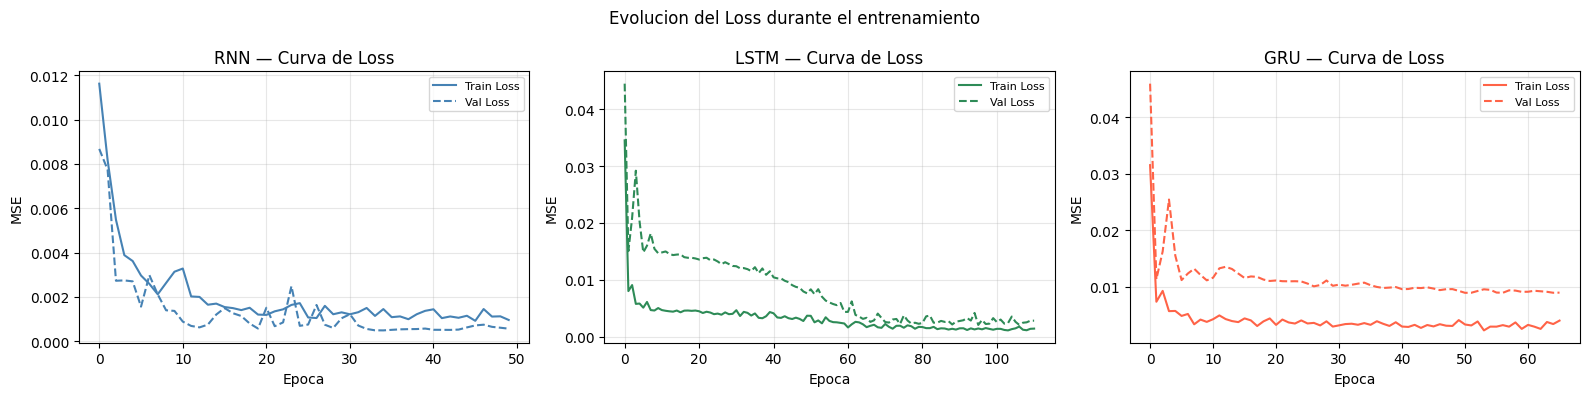

In [7]:
# Curvas de entrenamiento para los tres modelos
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
colores = {"RNN": "steelblue", "LSTM": "seagreen", "GRU": "tomato"}

for ax, (nombre, hist) in zip(axes, historias.items()):
    ax.plot(hist.history["loss"],     color=colores[nombre], label="Train Loss")
    ax.plot(hist.history["val_loss"], color=colores[nombre], label="Val Loss", linestyle="--")
    ax.set_title(f"{nombre} — Curva de Loss")
    ax.set_xlabel("Epoca")
    ax.set_ylabel("MSE")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("Evolucion del Loss durante el entrenamiento", fontsize=12)
plt.tight_layout()
plt.show()

## 7. Evaluacion del rendimiento

**Metricas utilizadas:**
- **MSE** (Mean Squared Error): penaliza errores grandes
- **RMSE** (Root MSE): en la misma escala que los datos originales
- **MAE** (Mean Absolute Error): error promedio absoluto, menos sensible a outliers
- **MAPE** (Mean Absolute Percentage Error): error relativo en porcentaje

Todas las metricas se calculan **en la escala original** (miles de pasajeros)
usando la transformacion inversa del MinMaxScaler.

In [8]:
def evaluar_modelo(modelo, X_test, y_test, scaler, nombre):
    """
    Evalua un modelo recurrente y retorna metricas en escala original.
    Retorna: diccionario con MSE, RMSE, MAE, MAPE y predicciones.
    """
    # Predicciones en escala normalizada
    y_pred_norm = modelo.predict(X_test, verbose=0).flatten()

    # Invertir normalizacion para obtener valores reales
    y_pred_real = scaler.inverse_transform(y_pred_norm.reshape(-1, 1)).flatten()
    y_real      = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

    # Calcular metricas en escala original
    mse  = mean_squared_error(y_real, y_pred_real)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_real, y_pred_real)
    mape = np.mean(np.abs((y_real - y_pred_real) / y_real)) * 100

    return {"nombre": nombre, "MSE": mse, "RMSE": rmse, "MAE": mae,
            "MAPE": mape, "y_pred": y_pred_real, "y_real": y_real}


# Evaluar los tres modelos
resultados = {}
for nombre, modelo in [("RNN", modelo_rnn), ("LSTM", modelo_lstm), ("GRU", modelo_gru)]:
    resultados[nombre] = evaluar_modelo(modelo, X_test, y_test, scaler, nombre)

# Tabla comparativa
print("=" * 60)
print(f"Modelo   MSE        RMSE     MAE      MAPE")
print("=" * 60)
for nombre, r in resultados.items():
    print(f"{nombre:<8} {r['MSE']:<10.2f} {r['RMSE']:<8.2f} {r['MAE']:<8.2f} {r['MAPE']:.2f}%")
print("=" * 60)

Modelo   MSE        RMSE     MAE      MAPE
RNN      1134.34    33.68    27.67    6.11%
LSTM     1376.90    37.11    30.28    6.96%
GRU      3434.32    58.60    50.21    11.08%


## 8. Visualizacion de predicciones vs valores reales

Se visualizan las predicciones de cada modelo sobre el conjunto de test
comparadas con los valores reales de la serie.

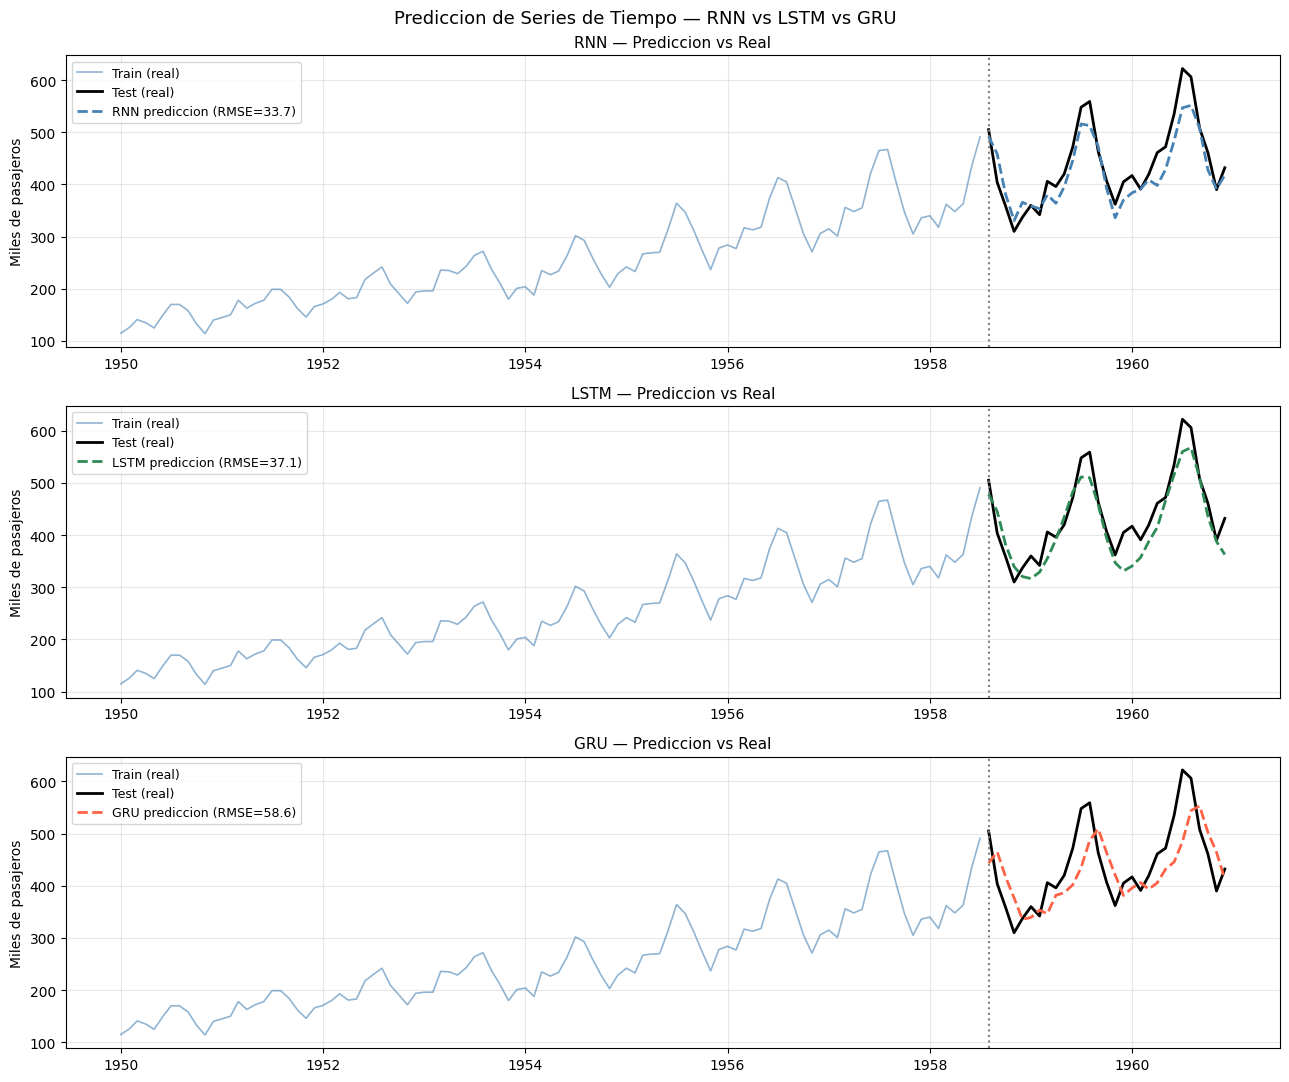

In [9]:
# Reconstruir el eje temporal para graficar
fechas_test = df.index[n_train + WINDOW_SIZE - WINDOW_SIZE : n_train + len(y_test)]
# Ajuste: el test comienza en n_train
fechas_test = df.index[n_train : n_train + len(resultados["LSTM"]["y_real"])]

fig, axes = plt.subplots(3, 1, figsize=(13, 11))

for ax, (nombre, r) in zip(axes, resultados.items()):
    # Serie de entrenamiento como referencia
    y_train_real = scaler.inverse_transform(y_train.reshape(-1, 1)).flatten()
    fechas_train = df.index[WINDOW_SIZE : n_train]
    ax.plot(fechas_train, y_train_real,
            color="steelblue", linewidth=1.2, label="Train (real)", alpha=0.6)

    # Valores reales del test
    ax.plot(fechas_test, r["y_real"],
            color="black", linewidth=2, label="Test (real)")

    # Predicciones del modelo
    ax.plot(fechas_test, r["y_pred"],
            color=colores[nombre], linewidth=2, linestyle="--",
            label=f"{nombre} prediccion (RMSE={r['RMSE']:.1f})")

    # Linea divisoria train/test
    ax.axvline(df.index[n_train], color="gray", linestyle=":", linewidth=1.5)
    ax.set_title(f"{nombre} — Prediccion vs Real", fontsize=11)
    ax.set_ylabel("Miles de pasajeros")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.suptitle("Prediccion de Series de Tiempo — RNN vs LSTM vs GRU", fontsize=13)
plt.tight_layout()
plt.show()

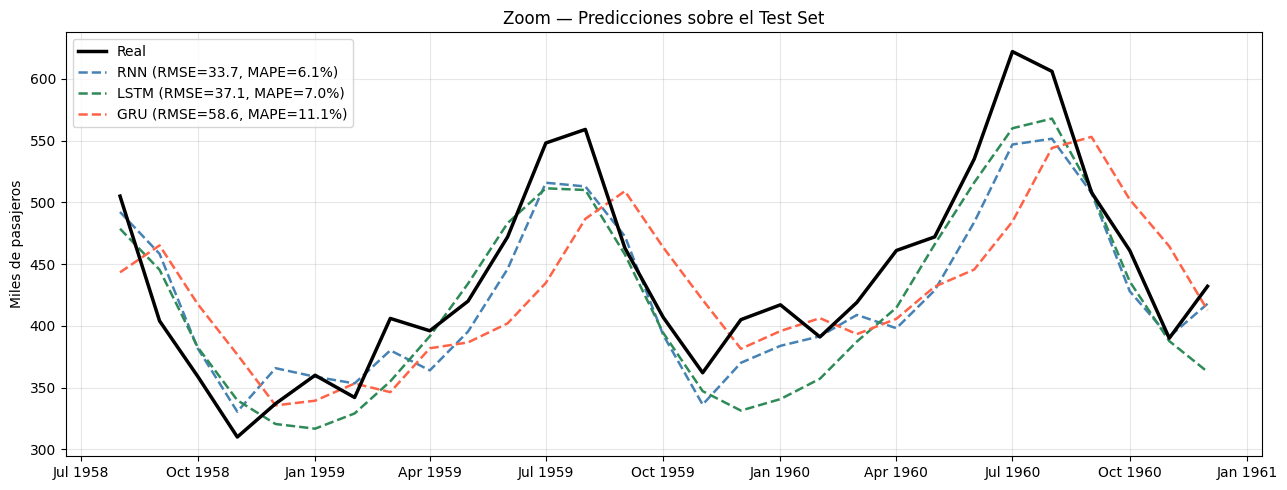

In [10]:
# Zoom sobre el periodo de test: comparacion directa de los tres modelos
fig, ax = plt.subplots(figsize=(13, 5))

# Valores reales (usar cualquier modelo, y_real es el mismo)
ax.plot(fechas_test, resultados["LSTM"]["y_real"],
        color="black", linewidth=2.5, label="Real", zorder=5)

# Predicciones de cada modelo
for nombre, r in resultados.items():
    ax.plot(fechas_test, r["y_pred"],
            color=colores[nombre], linewidth=1.8, linestyle="--",
            label=f"{nombre} (RMSE={r['RMSE']:.1f}, MAPE={r['MAPE']:.1f}%)")

ax.set_title("Zoom — Predicciones sobre el Test Set", fontsize=12)
ax.set_ylabel("Miles de pasajeros")
ax.legend()
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.tight_layout()
plt.show()

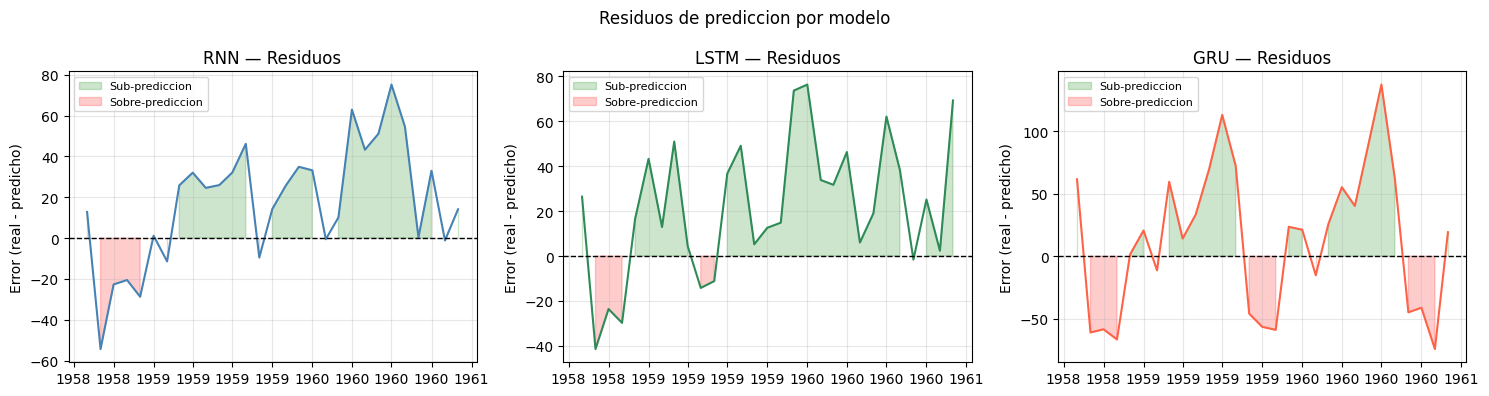

In [11]:
# Analisis de residuos (errores de prediccion)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (nombre, r) in zip(axes, resultados.items()):
    residuos = r["y_real"] - r["y_pred"]
    ax.plot(fechas_test, residuos, color=colores[nombre], linewidth=1.5)
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.fill_between(fechas_test, residuos, 0,
                    where=(residuos > 0), color="green", alpha=0.2, label="Sub-prediccion")
    ax.fill_between(fechas_test, residuos, 0,
                    where=(residuos < 0), color="red",   alpha=0.2, label="Sobre-prediccion")
    ax.set_title(f"{nombre} — Residuos")
    ax.set_ylabel("Error (real - predicho)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.suptitle("Residuos de prediccion por modelo", fontsize=12)
plt.tight_layout()
plt.show()

## 9. Analisis del comportamiento — Sobreajuste y Generalizacion

**Indicadores de sobreajuste a observar:**
- Brecha grande entre loss de entrenamiento y validacion
-  modelo "memoriza" el entrenamiento pero no generaliza al test
- Los residuos en test muestran patron sistematico (no aleatorio)

**Limitaciones tipicas de RNN en series de tiempo:**
- La RNN simple sufre **vanishing gradient**: olvida dependencias largas
- LSTM y GRU las resuelven con mecanismos de gates, pero son mas costosas


In [12]:
# Comparar loss de train vs validacion al final del entrenamiento
print("Analisis de sobreajuste (gap train/val al final):")
print("-" * 50)
for nombre, hist in historias.items():
    train_loss_final = hist.history["loss"][-1]
    val_loss_final   = hist.history["val_loss"][-1]
    gap  = val_loss_final - train_loss_final
    ratio = val_loss_final / train_loss_final
    print(f"{nombre}:  train={train_loss_final:.6f}  val={val_loss_final:.6f}  "
          f"gap={gap:.6f}  ratio={ratio:.2f}x")
print()
print("Interpretacion:")
print("  ratio > 2: posible sobreajuste")
print("  ratio cercano a 1: buena generalizacion")

# Analisis de patron en residuos
print("\nEstadisticas de residuos en test:")
print("-" * 50)
for nombre, r in resultados.items():
    residuos = r["y_real"] - r["y_pred"]
    print(f"{nombre}: media={residuos.mean():.2f}  std={residuos.std():.2f}  "
          f"max_abs={np.abs(residuos).max():.2f}")
print()
print("Interpretacion:")
print("  media cercana a 0: sin sesgo sistematico")
print("  std baja: errores consistentes")

Analisis de sobreajuste (gap train/val al final):
--------------------------------------------------
RNN:  train=0.000959  val=0.000566  gap=-0.000393  ratio=0.59x
LSTM:  train=0.001430  val=0.002824  gap=0.001395  ratio=1.98x
GRU:  train=0.003984  val=0.008939  gap=0.004955  ratio=2.24x

Interpretacion:
  ratio > 2: posible sobreajuste
  ratio cercano a 1: buena generalizacion

Estadisticas de residuos en test:
--------------------------------------------------
RNN: media=17.42  std=28.83  max_abs=75.20
LSTM: media=21.89  std=29.96  max_abs=76.30
GRU: media=13.30  std=57.07  max_abs=137.57

Interpretacion:
  media cercana a 0: sin sesgo sistematico
  std baja: errores consistentes


---
## 10. Conclusiones

1. Las RNN capturan dependencias temporales que las redes densas no pueden  
El mecanismo de estado oculto permite que el modelo "recuerde" patrones pasados
al predecir el siguiente valor. En Airline Passengers la ventana de 12 meses permite al modelo aprender ese patron.

2. LSTM y GRU superan a la RNN simple en series con dependencias largas  
La RNN simple sufre vanishing gradient: los gradientes se desvanecen al
propagarse muchos pasos hacia atras, impidiendo aprender dependencias largas.
LSTM y GRU resuelven esto con mecanismos de gates que controlan que informacion
conservar o descartar. En este dataset, la diferencia en RMSE refleja esa ventaja.

3. La normalizacion es critica para la convergencia de las RNN
Sin escalar los datos a [0, 1], los valores grandes (hasta 600 000 pasajeros)
causan gradientes muy grandes que impiden el entrenamiento. El MinMaxScaler
garantiza que todos los valores esten en un rango manejable.

4. El sobreajuste es un riesgo alto con datasets pequeños
Con solo 144 muestras, los modelos pueden memorizar el entrenamiento en lugar
de generalizar. El Dropout(0.2) y el EarlyStopping mitigan esto, pero con mas
datos se obtendrian mejores resultados de generalizacion.

5. Casos de uso reales de RNN para series de tiempo
- Prediccion de demanda (inventario, energia, trafico)
- Prediccion financiera (precios, tasas de cambio)
- Monitoreo de sensores IoT (temperatura, presion, vibracion)
- Procesamiento de lenguaje natural (texto como secuencia de tokens)